In [1]:
#Importing required statements
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve, mean_squared_error, r2_score, RocCurveDisplay
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor


In [2]:
DATA_DIR = Path(".")
# Creating full paths to the training and scoring Excel files.
TRAIN_FILE = DATA_DIR / "nonprofit.xlsx"
SCORE_FILE = DATA_DIR / "nonprofit_score.xlsx"

# Setting a pandas display option to show up to 60 columns when printing dataframes.
pd.set_option('display.max_columns', 60)


In [3]:
# Loading the training and scoring datasets from Excel files
train = pd.read_excel(TRAIN_FILE)
score = pd.read_excel(SCORE_FILE)

# Normalizing column names to lowercase for robustness
train.columns = [c.lower() for c in train.columns]
score.columns = [c.lower() for c in score.columns]

# Printing the number of rows and columns in each dataset
print("Training data shape:", train.shape)
print("Score data shape:", score.shape)
# Displaying the first few rows of the training dataset for a quick preview
display(train.head())
# Showing the data types and structure of the training dataset
display(train.info())


Training data shape: (6002, 20)
Score data shape: (2007, 19)


,id,region,ownd,kids,inc,sex,wlth,hv,incmed,incavg,low,npro,gifdol,gifl,gifr,mdon,lag,gifa,donr,damt
0,1,ter3,1,1,4,1,8,302,76,82,0,20,81,81,19,17,6,21.05,0,0
1,2,ter3,1,2,4,0,8,262,130,130,1,95,156,16,17,19,3,13.26,1,15
2,5,ter3,1,0,4,1,4,295,39,71,14,85,132,15,10,10,6,12.07,1,17
3,6,ter2,1,1,5,0,9,114,17,25,44,83,131,5,3,13,4,4.12,1,12
4,7,ter5,1,3,4,0,8,145,39,42,10,50,74,6,5,22,3,6.50,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6002 entries, 0 to 6001
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      6002 non-null   int64  
 1   region  6002 non-null   object 
 2   ownd    6002 non-null   int64  
 3   kids    6002 non-null   int64  
 4   inc     6002 non-null   int64  
 5   sex     6002 non-null   int64  
 6   wlth    6002 non-null   int64  
 7   hv      6002 non-null   int64  
 8   incmed  6002 non-null   int64  
 9   incavg  6002 non-null   int64  
 10  low     6002 non-null   int64  
 11  npro    6002 non-null   int64  
 12  gifdol  6002 non-null   int64  
 13  gifl    6002 non-null   int64  
 14  gifr    6002 non-null   int64  
 15  mdon    6002 non-null   int64  
 16  lag     6002 non-null   int64  
 17  gifa    6002 non-null   float64
 18  donr    6002 non-null   int64  
 19  damt    6002 non-null   int64  
dtypes: float64(1), int64(18), object(1)
memory usage: 937.9+ KB


None

# EDA

In [4]:
# Printing all column names to understand the available features in the dataset
print("Columns:", train.columns.tolist())
# Calculating and display the donor rate (proportion of records where donr = 1)
print("\nDonor rate in training data:", train['donr'].mean())

# Generating descriptive statistics for all columns, including categorical variables
display(train.describe(include='all').T)


Columns: ['id', 'region', 'ownd', 'kids', 'inc', 'sex', 'wlth', 'hv', 'incmed', 'incavg', 'low', 'npro', 'gifdol', 'gifl', 'gifr', 'mdon', 'lag', 'gifa', 'donr', 'damt']

Donor rate in training data: 0.49883372209263577


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,6002.0,NaN,NaN,NaN,3978.908197,2301.807612,1.0,1985.25,3945.5,5963.75,8009.0
region,6002,5,ter2,2083,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ownd,6002.0,NaN,NaN,NaN,0.884538,0.319605,0.0,1.0,1.0,1.0,1.0
kids,6002.0,NaN,NaN,NaN,1.583972,1.412455,0.0,0.0,2.0,3.0,5.0
inc,6002.0,NaN,NaN,NaN,3.93902,1.401887,1.0,3.0,4.0,5.0,7.0
sex,6002.0,NaN,NaN,NaN,0.607797,0.488282,0.0,0.0,1.0,1.0,1.0
wlth,6002.0,NaN,NaN,NaN,7.023159,2.330964,0.0,6.0,8.0,9.0,9.0
hv,6002.0,NaN,NaN,NaN,183.905365,72.77051,51.0,134.0,170.0,218.0,710.0
incmed,6002.0,NaN,NaN,NaN,43.94885,24.664411,3.0,27.0,38.0,55.0,287.0
incavg,6002.0,NaN,NaN,NaN,56.789404,24.833503,14.0,40.0,52.0,68.0,287.0


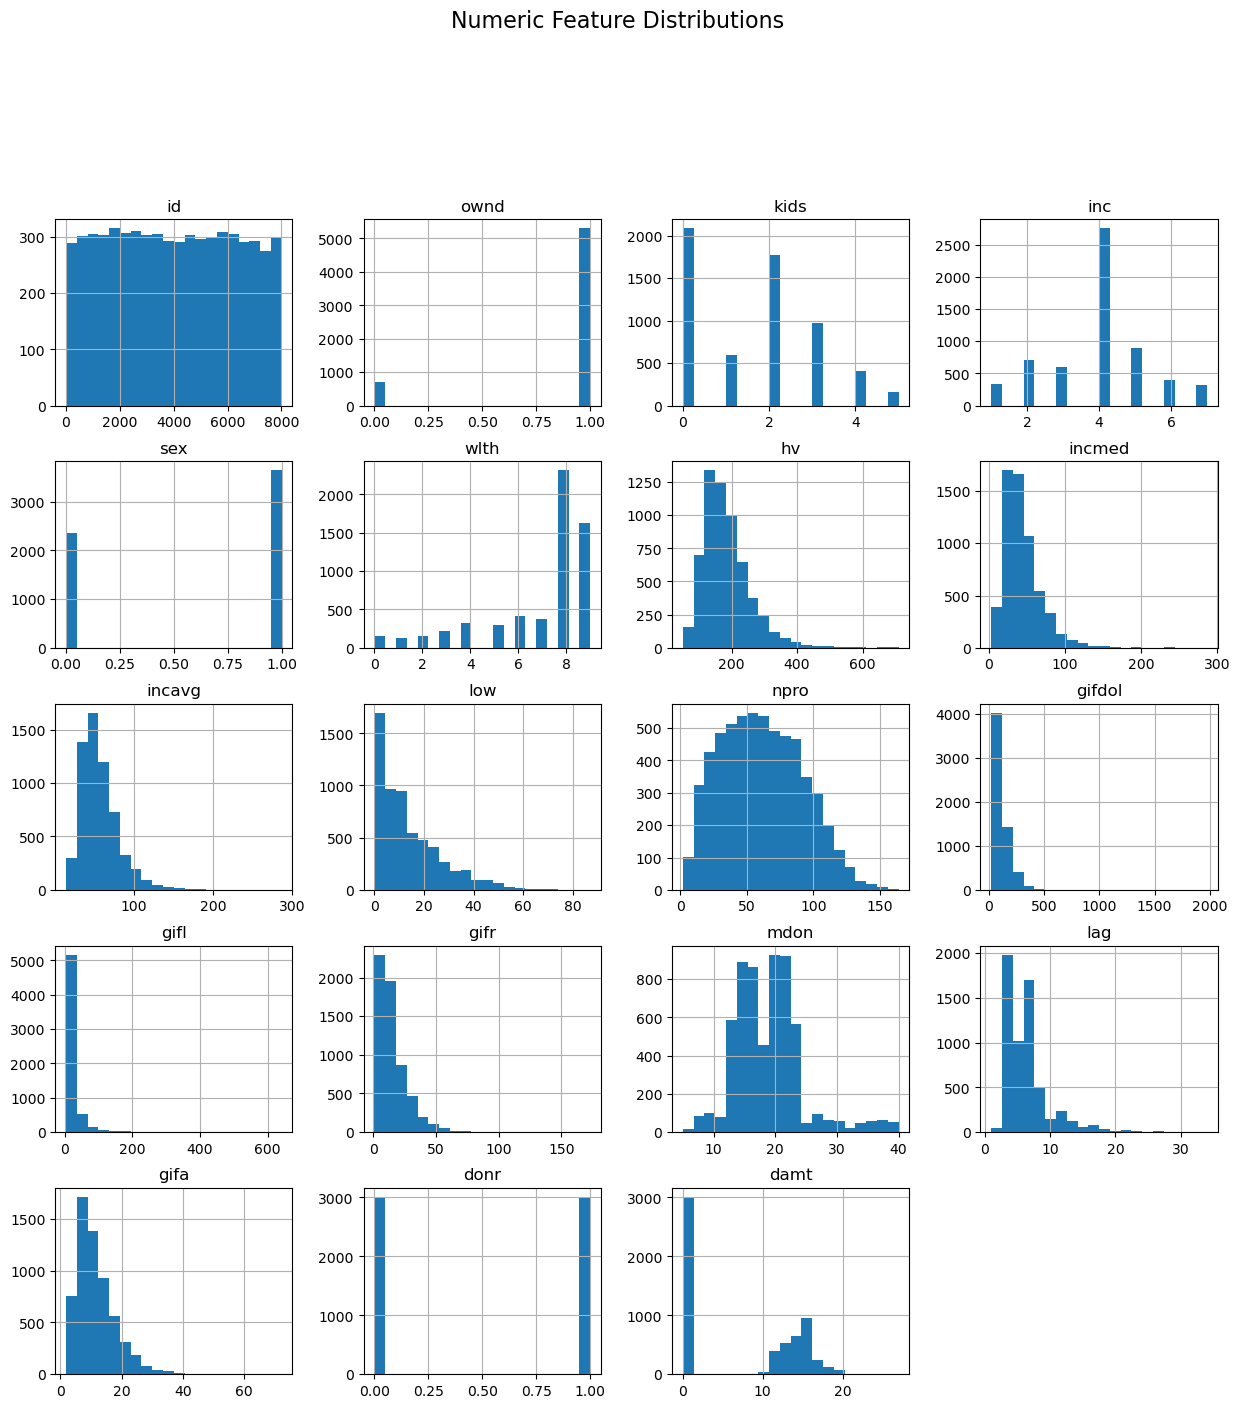

In [5]:
#Histogram for Numeric Features
# Identifying all numeric columns in the dataset (integers and floats)
numeric_cols = train.select_dtypes(include=['float', 'int']).columns

# Plotting histograms for all numeric features to examine their distributions
train[numeric_cols].hist(bins=20, figsize=(15, 15))
# Adding a title for the entire figure
plt.suptitle("Numeric Feature Distributions", y=1.02, fontsize=16)
#Displaying plot
plt.show()


(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5]),
 [Text(0, 0.5, 'id'),
  Text(0, 1.5, 'ownd'),
  Text(0, 2.5, 'kids'),
  Text(0, 3.5, 'inc'),
  Text(0, 4.5, 'sex'),
  Text(0, 5.5, 'wlth'),
  Text(0, 6.5, 'hv'),
  Text(0, 7.5, 'incmed'),
  Text(0, 8.5, 'incavg'),
  Text(0, 9.5, 'low'),
  Text(0, 10.5, 'npro'),
  Text(0, 11.5, 'gifdol'),
  Text(0, 12.5, 'gifl'),
  Text(0, 13.5, 'gifr'),
  Text(0, 14.5, 'mdon'),
  Text(0, 15.5, 'lag'),
  Text(0, 16.5, 'gifa'),
  Text(0, 17.5, 'donr'),
  Text(0, 18.5, 'damt')])

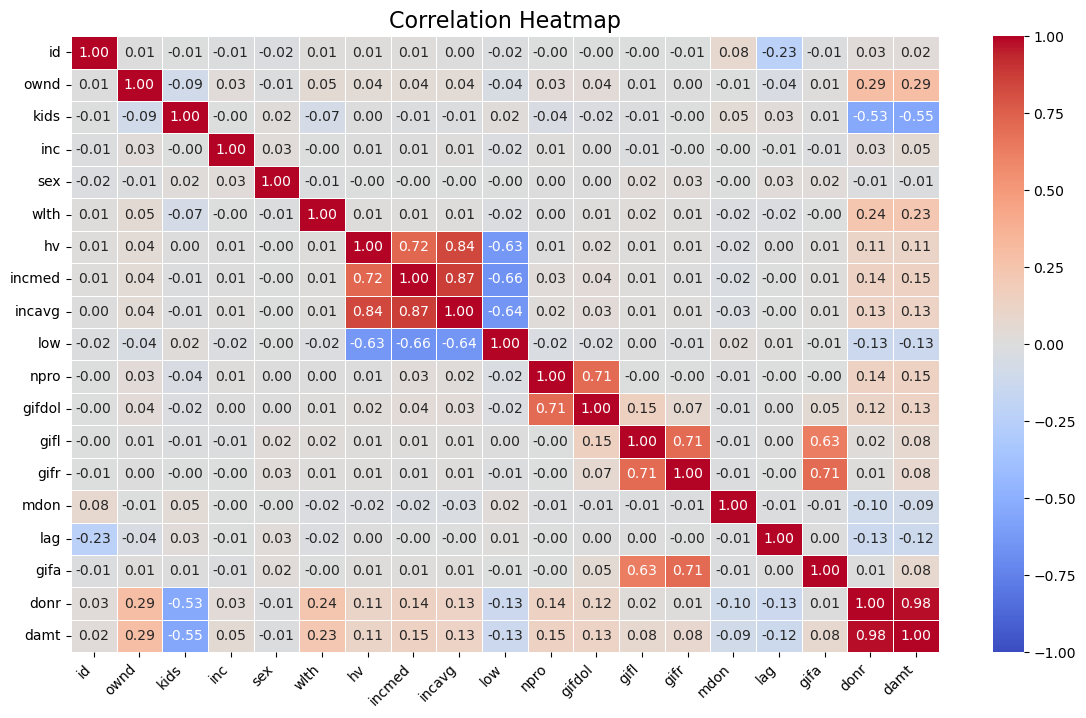

In [29]:
# Select only numeric columns for correlation analysis
numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns
 
# Compute the correlation matrix using numeric features
corr_matrix = train[numeric_cols].corr()
 
# Plot the correlation heatmap
plt.figure(figsize=(14, 8))
 
# Create heatmap with annotations and color scale
sns.heatmap(
    corr_matrix,
    annot=True,          # show correlation values
    fmt=".2f",           # format numbers to 2 decimals
    cmap="coolwarm",     # color map for positive/negative correlation
    linewidths=0.5,      # thin lines between squares
    linecolor='white',   # line color between cells
    vmin=-1, vmax=1      # fixed range for correlation values
)
 
# Add title and adjust axis labels
plt.title("Correlation Heatmap", fontsize=16)
plt.xticks(rotation=45, ha='right')  # rotate x-axis labels for readability
plt.yticks(rotation=0)

<Figure size 1200x800 with 0 Axes>

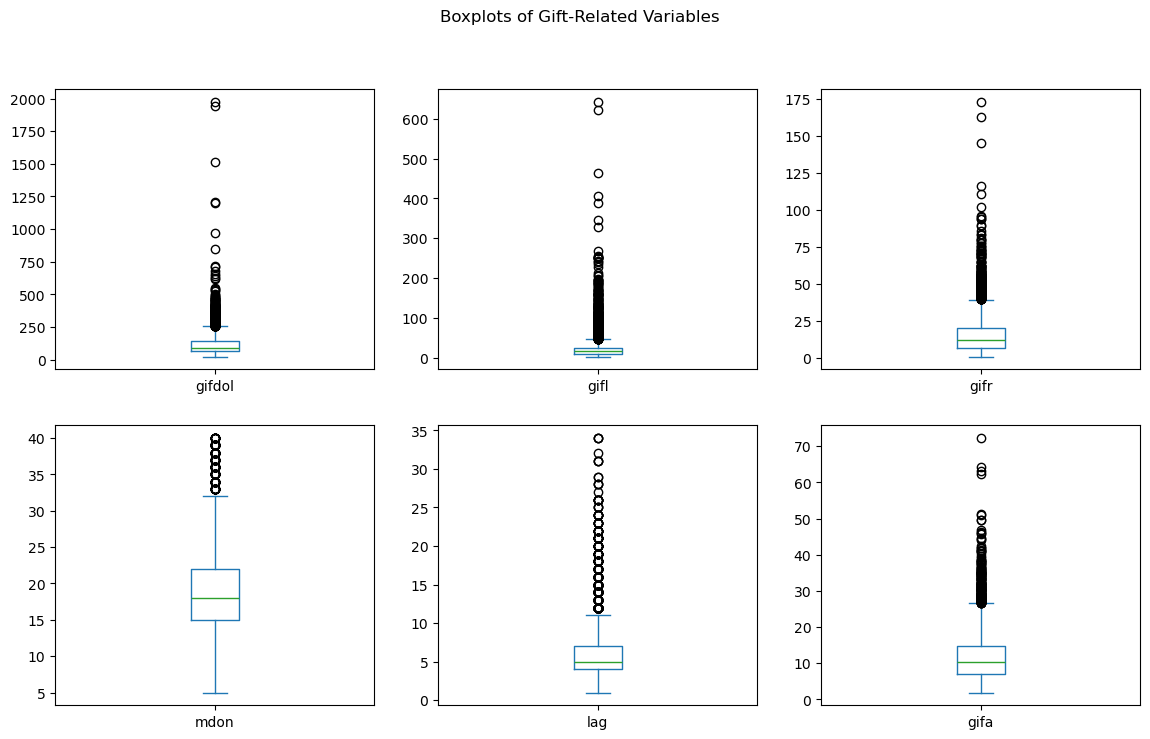

In [7]:
#Boxplots for Behavior Variables
# List of gift-related variables to visualize
gift_vars = ['gifdol', 'gifl', 'gifr', 'mdon', 'lag', 'gifa']
# Creating a figure for multiple boxplots
plt.figure(figsize=(12, 8))
# Plotting each gift-related variable as a separate boxplot
train[gift_vars].plot(kind='box', subplots=True, layout=(2,3), figsize=(14,8), sharex=False)
# Adding a title for the full figure
plt.suptitle("Boxplots of Gift-Related Variables")
# Displaying the plots
plt.show()


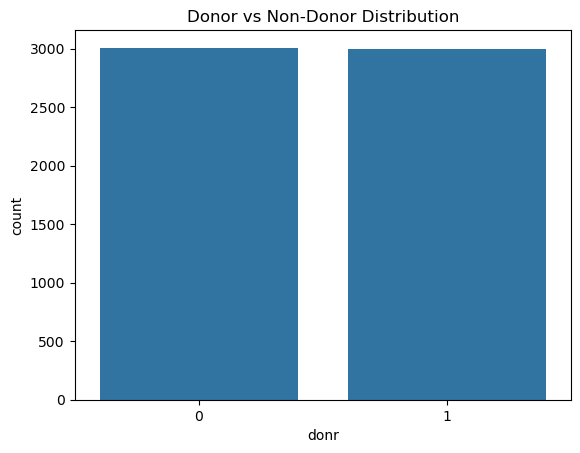

In [8]:
#Donor vs Non-Donor Counts
# Plotting the count of donor (1) vs non-donor (0) observations
sns.countplot(data=train, x='donr')
# Adding a descriptive title
plt.title("Donor vs Non-Donor Distribution")
# Displaying the plot
plt.show()

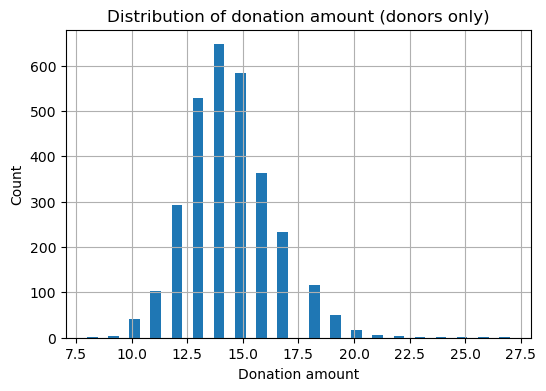

In [9]:
# donation amount distribution among donors
# Creating a histogram of donation amounts, but only for donor records (donr = 1)
plt.figure(figsize=(6,4))
train.loc[train['donr']==1, 'damt'].hist(bins=40)
# Adding plot labels and title
plt.title("Distribution of donation amount (donors only)")
plt.xlabel("Donation amount")
plt.ylabel("Count")
# Displaying the plot
plt.show()

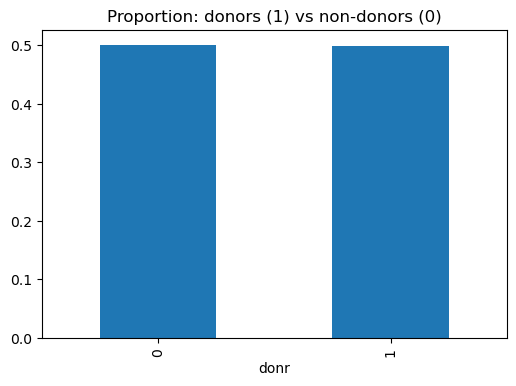

In [10]:
# Visuals- donor distribution and donation amount among donors
# Plotting the proportion (percentage) of donor vs non-donor records
plt.figure(figsize=(6,4))
train['donr'].value_counts(normalize=True).plot(kind='bar')
# Adding a descriptive title
plt.title("Proportion: donors (1) vs non-donors (0)")
# Displaying the plot
plt.show()


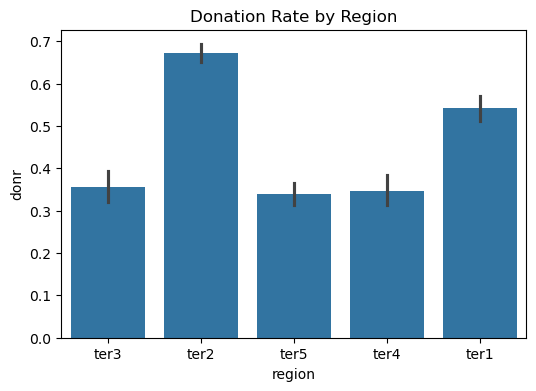

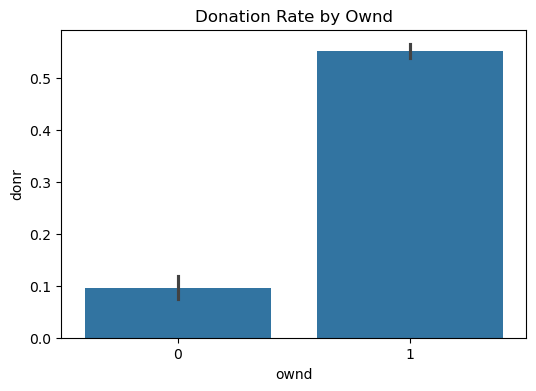

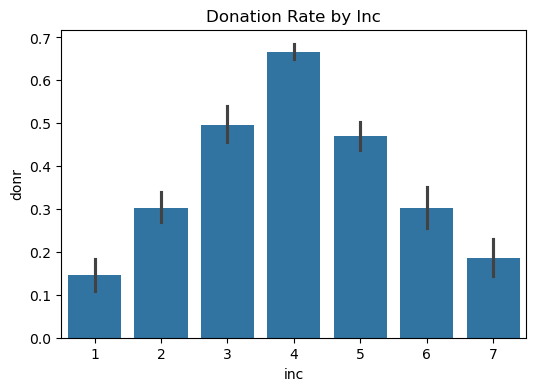

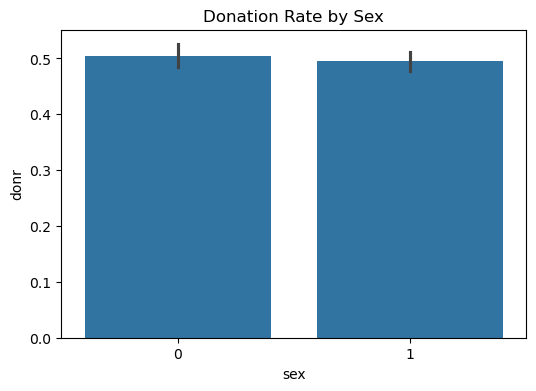

In [11]:
#Categorical Variables vs Donation Rate
# List of categorical columns to analyze
categorical_cols = ['region','ownd','inc','sex']

# Looping through each categorical variable to plot average donation rate
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.barplot(x=col, y='donr', data=train)
    # Add a descriptive title for each plot
    plt.title(f"Donation Rate by {col.capitalize()}")
    # Display the plot
    plt.show()


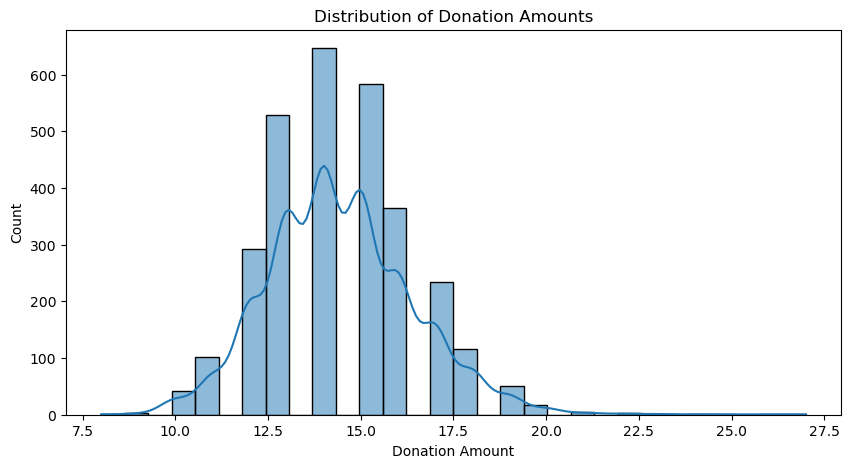

In [12]:
#Donation Amount Distribution (only donors)
donors = train[train['donr'] == 1]

plt.figure(figsize=(10,5))
sns.histplot(donors['damt'], bins=30, kde=True)
plt.title("Distribution of Donation Amounts")
plt.xlabel("Donation Amount")
#Displaying plot
plt.show()


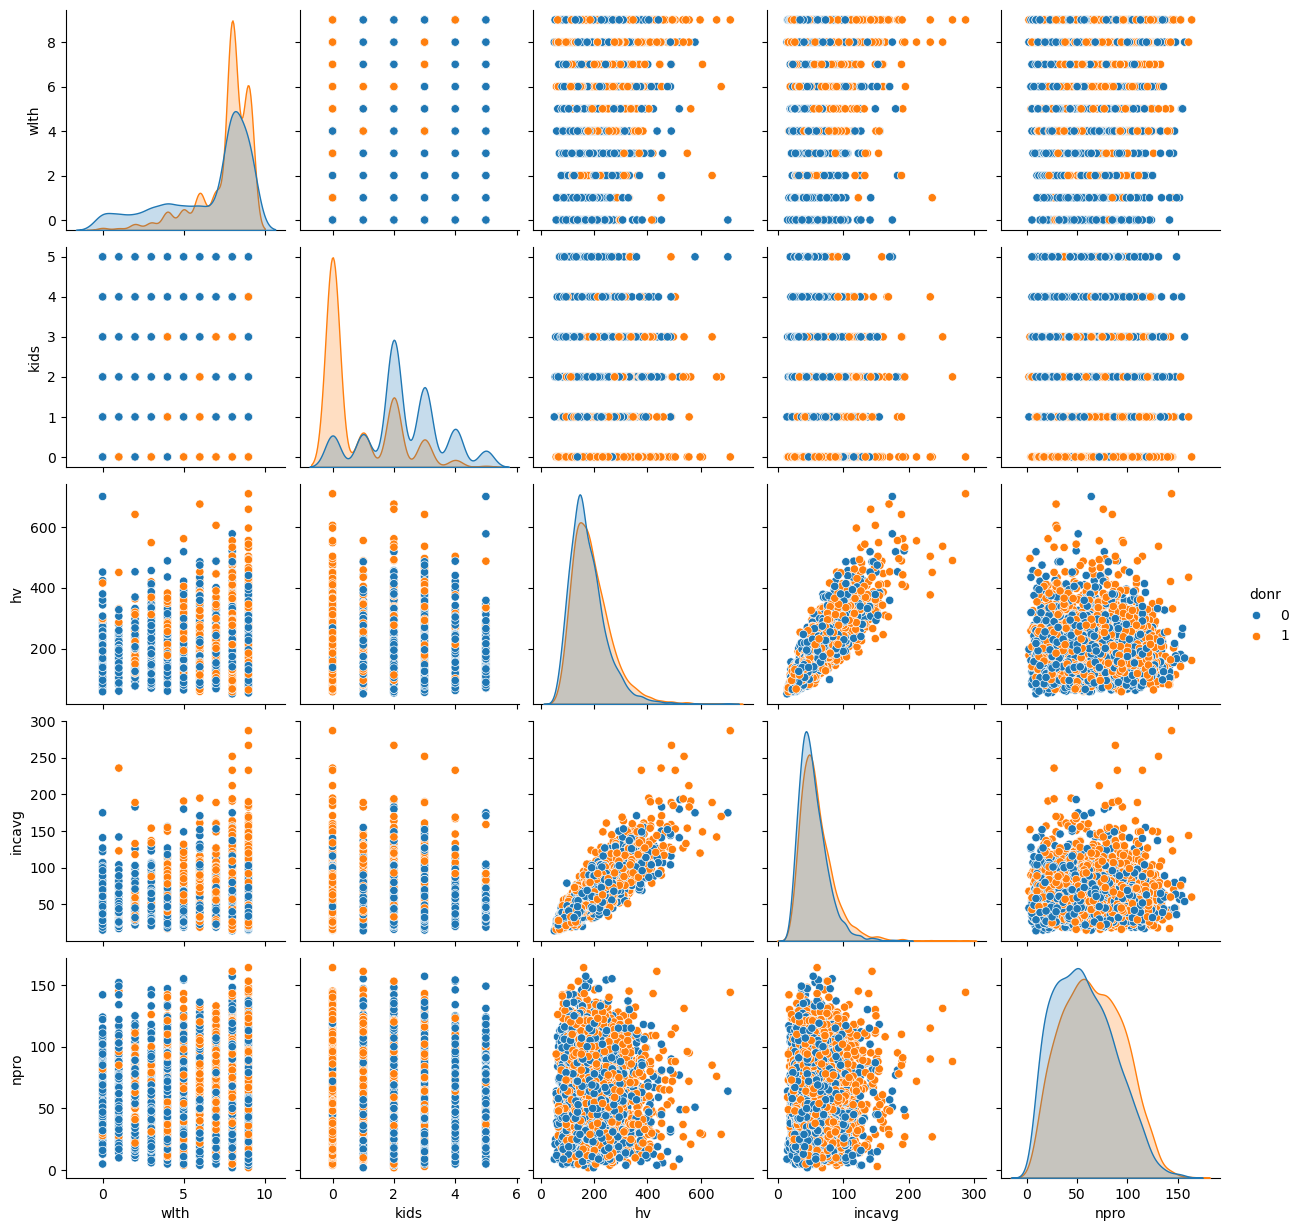

In [13]:
#Pairplot of Important Predictors
sns.pairplot(train[['donr','wlth','kids','hv','incavg','npro']], hue='donr')
#Displaying plot
plt.show()

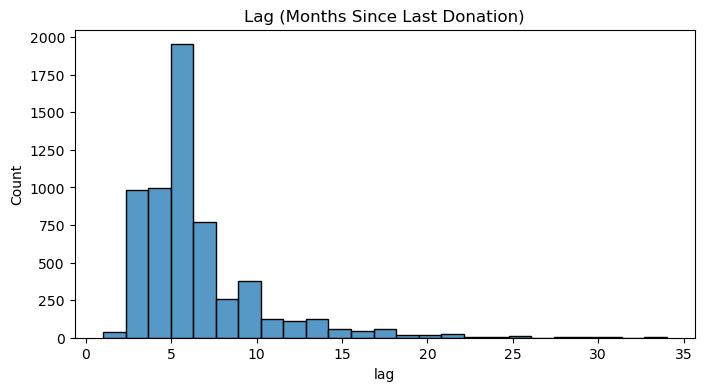

In [14]:
#Distribution of Gift Lag Time (lag)
plt.figure(figsize=(8,4))
sns.histplot(train['lag'], bins=25)
plt.title("Lag (Months Since Last Donation)")
#Displaying plot
plt.show()


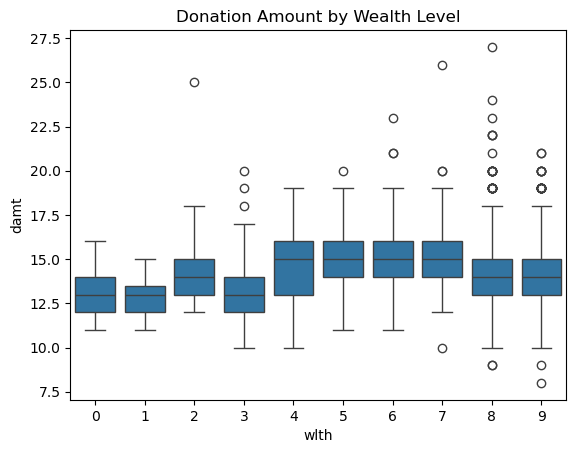

In [15]:
#Relationship: Wealth vs Donation Amount
sns.boxplot(data=donors, x='wlth', y='damt')
plt.title("Donation Amount by Wealth Level")
#Displaying plot
plt.show()

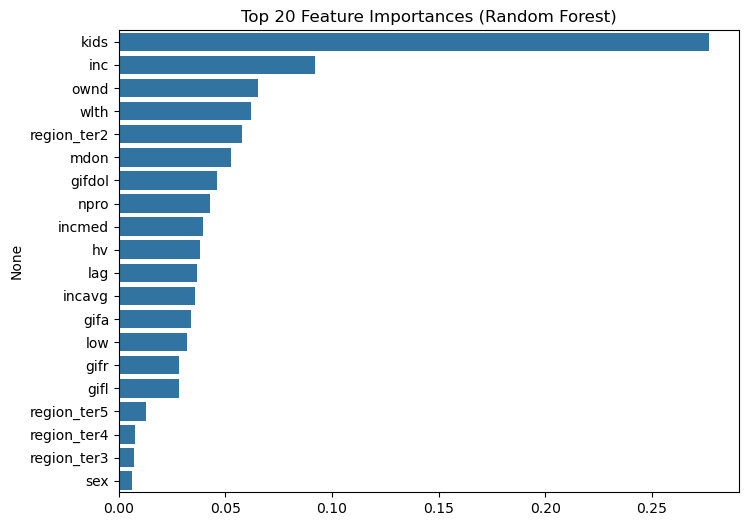

In [16]:
#Random Forest- Feature Importance 

# simple baseline model
features = train.drop(columns=['id','donr','damt'], errors='ignore')
labels = train['donr']

# convert categoricals
features_enc = pd.get_dummies(features, drop_first=True)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(features_enc, labels)

importances = pd.Series(rf.feature_importances_, index=features_enc.columns)
top_feats = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(8,6))
sns.barplot(x=top_feats.values, y=top_feats.index)
plt.title("Top 20 Feature Importances (Random Forest)")
#Displaying plot
plt.show()


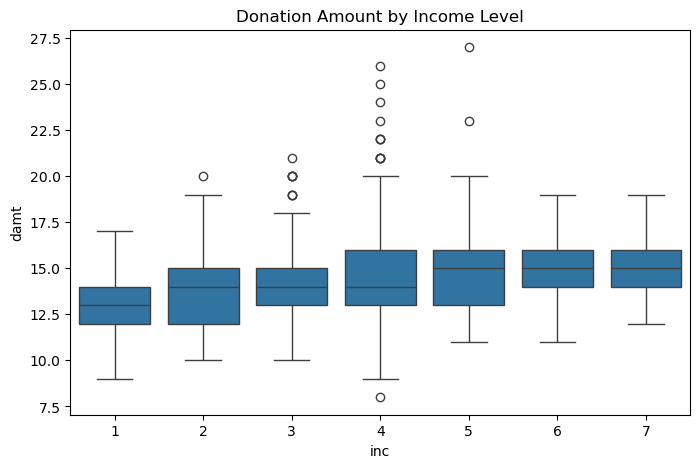

In [17]:
#Donation Amount vs Income Category
plt.figure(figsize=(8,5))
sns.boxplot(data=donors, x='inc', y='damt')
plt.title("Donation Amount by Income Level")
#Displaying plot
plt.show()

/var/folders/2h/d72vcx3n45q8sr7vv6zmq2q40000gp/T/ipykernel_38110/3604854756.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(train['gifa'], shade=True)


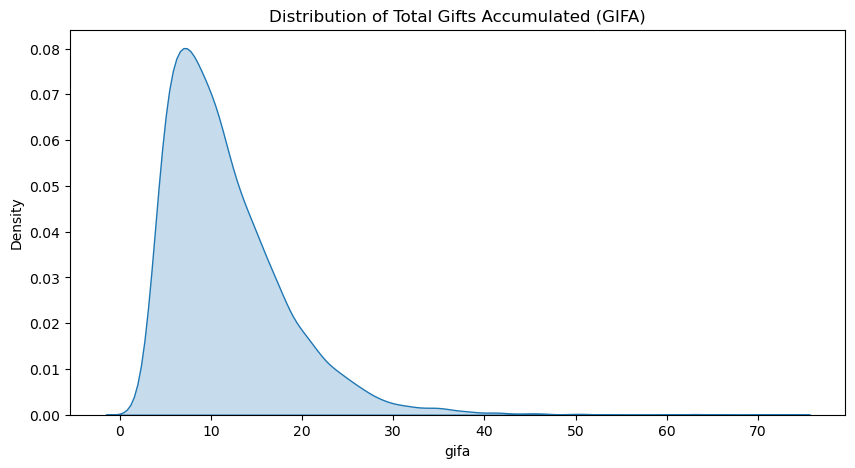

In [18]:
#Distribution of Total Gifts (gifa)
plt.figure(figsize=(10,5))
sns.kdeplot(train['gifa'], shade=True)
plt.title("Distribution of Total Gifts Accumulated (GIFA)")
#Displaying plot
plt.show()

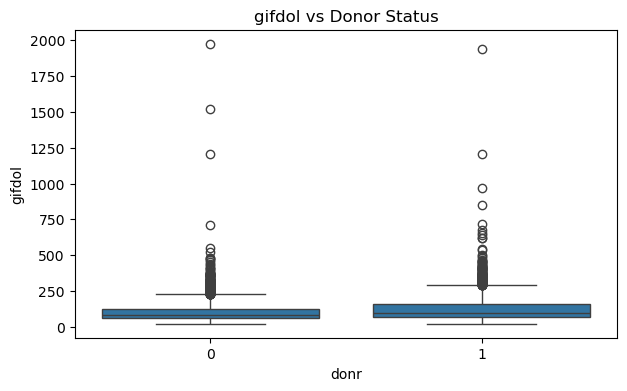

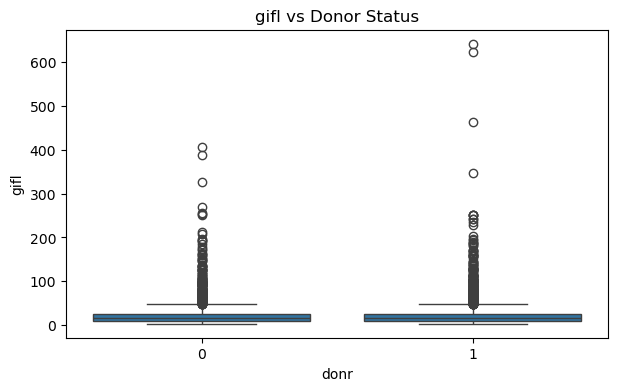

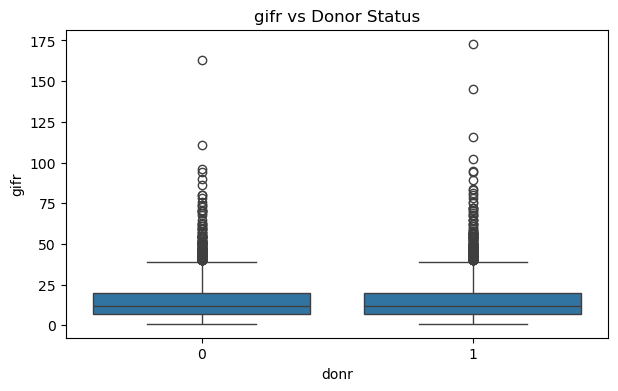

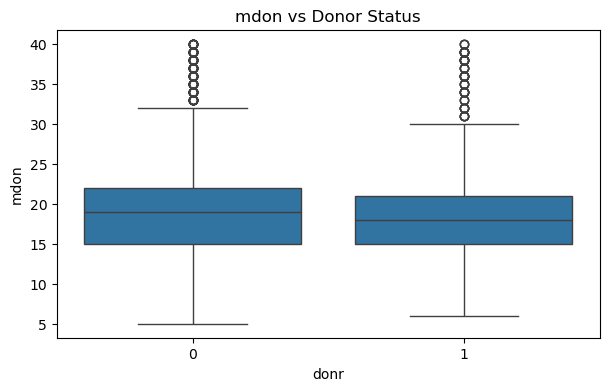

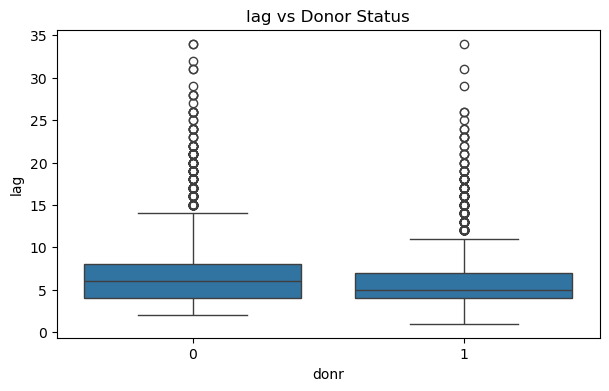

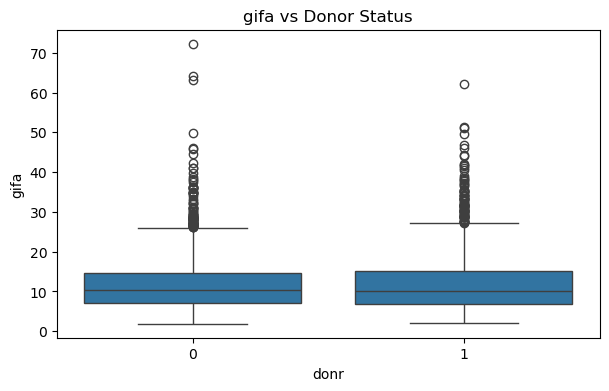

In [19]:
#Compare Gift History Between Donors & Non-Donors
vars_to_plot = ['gifdol','gifl','gifr','mdon','lag','gifa']

for var in vars_to_plot:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=train, x='donr', y=var)
    plt.title(f"{var} vs Donor Status")
    #Displaying plot
    plt.show()


In [20]:
# Prepare feature lists based on data dictionary
numeric_features = [f for f in ['kids','wlth','hv','incmed','incavg','low','npro','gifdol','gifl','gifr','mdon','lag','gifa'] if f in train.columns]
categorical_features = [f for f in ['region','ownd','inc','sex'] if f in train.columns]

# Creating preprocessing transformers
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print("Numeric features used:", numeric_features)
print("Categorical features used:", categorical_features)


Numeric features used: ['kids', 'wlth', 'hv', 'incmed', 'incavg', 'low', 'npro', 'gifdol', 'gifl', 'gifr', 'mdon', 'lag', 'gifa']
Categorical features used: ['region', 'ownd', 'inc', 'sex']


In [21]:

X = train.drop(columns=[c for c in ['id','damt'] if c in train.columns])
y = train['donr']

# Train and validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Train size:", X_train.shape, "Validation size:", X_val.shape)


Train size: (4501, 18) Validation size: (1501, 18)


In [22]:
# classification models

clf_candidates = {
    
    # 1. Logistic Regression
    'logistic': Pipeline([
        ('pre', preprocessor),
        ('clf', LogisticRegression(max_iter=2000))
    ]),

    # 2. Random Forest
    'random_forest': Pipeline([
        ('pre', preprocessor),
        ('clf', RandomForestClassifier(n_estimators=250, max_depth=10, random_state=42))
    ]),

    # 3. Gradient Boosting
    'gradient_boost': Pipeline([
        ('pre', preprocessor),
        ('clf', GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42))
    ]),

    # 4. KNN Classifier
    'knn': Pipeline([
        ('pre', preprocessor),
        ('clf', KNeighborsClassifier(n_neighbors=7))
    ]),

    # 5. Support Vector Classifier
    'svc': Pipeline([
        ('pre', preprocessor),
        ('clf', SVC(kernel='rbf', probability=True))
    ]),

    # 6. Gaussian Naive Bayes
    'naive_bayes': Pipeline([
        ('pre', preprocessor),
        ('clf', GaussianNB())
    ]),

    # 7. Neural Network (MLP)
    'mlp': Pipeline([
        ('pre', preprocessor),
        ('clf', MLPClassifier(hidden_layer_sizes=(64, 32),
                              max_iter=500,
                              activation='relu',
                              random_state=42))
    ])
}


In [23]:
def profit_by_threshold(y_true, probs, donation_amount=14.5, cost=2.0):
    thresholds = np.linspace(0, 1, 101)
    profits = []
    mailed = []

    for t in thresholds:
        send = probs >= t
        profit = ((y_true * donation_amount) - cost) * send
        profits.append(profit.sum())
        mailed.append(send.sum())

    best_i = int(np.nanargmax(profits))

    return {
        'thresholds': thresholds,
        'profits': np.array(profits),
        'mailed': np.array(mailed),
        'best_threshold': thresholds[best_i],
        'best_profit': profits[best_i],
        'best_mailed': mailed[best_i]
    }


In [24]:
results_clf = {}

for name, model in clf_candidates.items():

    model.fit(X_train, y_train)
    probs_val = model.predict_proba(X_val)[:, 1]

    auc = roc_auc_score(y_val, probs_val)
    profit_info = profit_by_threshold(y_val.values, probs_val)

    results_clf[name] = {
        'model': model,
        'auc': auc,
        'profit_info': profit_info
    }

    print(f"{name.upper()}")
    print(f"  → AUC: {auc:.3f}")
    print(f"  → Best Profit: ${profit_info['best_profit']:.2f}")
    print(f"  → Best Threshold: {profit_info['best_threshold']:.2f}")
    print(f"  → Mailed: {profit_info['best_mailed']}")
    print("-" * 60)


LOGISTIC
  → AUC: 0.955
  → Best Profit: $8765.00
  → Best Threshold: 0.16
  → Mailed: 968
------------------------------------------------------------
RANDOM_FOREST
  → AUC: 0.970
  → Best Profit: $8822.00
  → Best Threshold: 0.38
  → Mailed: 896
------------------------------------------------------------
GRADIENT_BOOST
  → AUC: 0.976
  → Best Profit: $8927.50
  → Best Threshold: 0.22
  → Mailed: 923
------------------------------------------------------------
KNN
  → AUC: 0.922
  → Best Profit: $8585.50
  → Best Threshold: 0.29
  → Mailed: 1094
------------------------------------------------------------
SVC
  → AUC: 0.962
  → Best Profit: $8883.50
  → Best Threshold: 0.21
  → Mailed: 916
------------------------------------------------------------
NAIVE_BAYES
  → AUC: 0.884
  → Best Profit: $8052.00
  → Best Threshold: 0.41
  → Mailed: 962
------------------------------------------------------------
MLP
  → AUC: 0.941
  → Best Profit: $8465.00
  → Best Threshold: 0.01
  → Mailed: 8

In [25]:
# Identify the classifier with the highest profit
best_model = max(results_clf.items(),
                 key=lambda kv: kv[1]['profit_info']['best_profit'])[0]

# Displaying the name of the best-performing classifier
print("\nBest Classifier by Profit:", best_model)
# Retrieving the best classifier model object
best_clf = results_clf[best_model]['model']
# Retrieving the optimal decision threshold for the best classifier
best_clf_threshold = results_clf[best_model]['profit_info']['best_threshold']



Best Classifier by Profit: gradient_boost


Confusion Matrix:
 [[572 180]
 [  6 743]]


<Figure size 600x500 with 0 Axes>

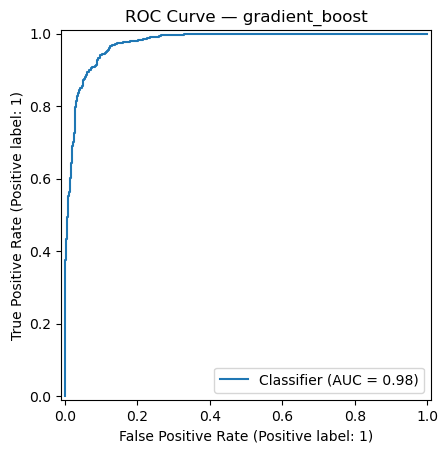

In [26]:
#Confusion Matrix & ROC Curve (Optional Plots)
# predictions using best threshold
probs_val = best_clf.predict_proba(X_val)[:,1]
preds_val = (probs_val >= best_clf_threshold).astype(int)

cm = confusion_matrix(y_val, preds_val)
print("Confusion Matrix:\n", cm)

# ROC Curve
plt.figure(figsize=(6,5))
RocCurveDisplay.from_predictions(y_val, probs_val)
plt.title(f"ROC Curve — {best_model}")
#Display plot
plt.show()


## Modeling - 2

In [27]:
# REGRESSION MODEL FOR DAMT

# We usually model donation amount only for donors (donr=1)
donors = train[train['donr'] == 1].copy()

# Features: drop id, donr, damt
X_regression = donors.drop(columns=[c for c in ['id', 'donr', 'damt'] if c in donors.columns])
y_regression = donors['damt']

# Train and validation split for regression
Xregression_train, Xregression_val, yregression_train, yregression_val = train_test_split(
    X_regression, y_regression, test_size=0.25, random_state=42
)

print("Regression Train size:", Xregression_train.shape, "Validation size:", Xregression_val.shape)

# Using the same preprocessor (numeric + categorical)


reg_candidates = {
    # Linear Regression
    'linear_regression': Pipeline([
        ('pre', preprocessor),
        ('reg', LinearRegression())
    ]),
    
    # Random Forest Regressor
    'rf_regressor': Pipeline([
        ('pre', preprocessor),
        ('reg', RandomForestRegressor(
            n_estimators=300,
            max_depth=10,
            random_state=42
        ))
    ]),
    
    # Gradient Boosting Regressor
    'gb_regressor': Pipeline([
        ('pre', preprocessor),
        ('reg', GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]),
    
    # KNN Regressor
    'knn_regressor': Pipeline([
        ('pre', preprocessor),
        ('reg', KNeighborsRegressor(n_neighbors=10))
    ])
}

reg_results = {}

for name, model in reg_candidates.items():
    print(f"\n{name.upper()}")
    model.fit(Xregression_train, yregression_train)
    preds_val = model.predict(Xregression_val)
    

    mse = mean_squared_error(yregression_val, preds_val)   # this is ASE
    rmse = np.sqrt(mse)                           # RMSE is sqrt of ASE
    ase = mse                                      # ASE = MSE
    r2 = r2_score(yregression_val, preds_val)
    
    reg_results[name] = {
        'model': model,
        'rmse': rmse,
        'ase': ase,
        'r2': r2
    }

    
    print(f"RMSE: {rmse:.2f}")
    print(f"ASE: {ase:.2f}")
    print(f"R²:  {r2:.3f}")

# Picking best regression model by RMSE (lower is better)
best_reg_name = min(reg_results.items(), key=lambda kv: kv[1]['rmse'])[0]
best_reg = reg_results[best_reg_name]['model']

#printing the best regression model
print("\nBest regression model by RMSE:", best_reg_name)
print(reg_results[best_reg_name])


Regression Train size: (2245, 17) Validation size: (749, 17)

LINEAR_REGRESSION
RMSE: 1.30
ASE: 1.70
R²:  0.555

RF_REGRESSOR
RMSE: 1.26
ASE: 1.58
R²:  0.584

GB_REGRESSOR
RMSE: 1.14
ASE: 1.30
R²:  0.659

KNN_REGRESSOR
RMSE: 1.42
ASE: 2.01
R²:  0.473

Best regression model by RMSE: gb_regressor
{'model': Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['kids', 'wlth', 'hv',
                                                   'incmed', 'incavg', 'low',
                                                   'npro', 'gifdol', 'gifl',
                                        

### Deployment

In [28]:
# DEPLOYMENT ON SCORE DATA and PROFIT

# Features for score data: drop id, donr, damt if present
X_score = score.drop(columns=[c for c in ['id', 'donr', 'damt'] if c in score.columns])

# Predicting probability of donating (DONR)
score_probs = best_clf.predict_proba(X_score)[:, 1]

# binary classification using the chosen threshold from validation
score_pred_donr = (score_probs >= best_clf_threshold).astype(int)

# Predicting donation amount (DAMT) using best regression model
score_pred_damt = best_reg.predict(X_score)

# Computing expected revenue and profit using probabilities
mail_cost = 2.0  # cost per mailing

# Expected revenue = P(donate) * predicted amount
expected_revenue_each = score_probs * score_pred_damt

# Expected profit per person = expected revenue - mailing cost
expected_profit_each = expected_revenue_each - mail_cost

# Strategy A: Mass Mailing (mail to everyone)

profit_mass_each = expected_profit_each           
total_profit_mass = profit_mass_each.sum()
avg_profit_per_mail_mass = profit_mass_each.mean()

# Strategy B: Targeted Mailing (Model-Based)
# Option: mail only if expected profit > 0

mask_mail = expected_profit_each > 0
# (Alternative rule if you want: mask_mail = score_probs >= best_clf_threshold)

# Count how many people are selected for mailing based on the mask
n_mail_target = mask_mail.sum()

# Filtering expected profit values only for those selected to be mailed
profit_target_each = expected_profit_each[mask_mail]
# Calculating total expected profit from the targeted mailing group
total_profit_target = profit_target_each.sum()
# Computing the average expected profit per mailed person in targeted strategy
avg_profit_per_mail_target = profit_target_each.mean()

# Title for the profit summary output
print("**PROFIT SUMMARY**")
# Displaying total number of records in the score dataset
print(f"Number in score file: {len(score)}")

# Section header for mass mailing results
print("\nMass Mailing")
# Showing total expected profit if everyone is mailed
print(f"Total expected profit: ${total_profit_mass:,.2f}")
# Showing average profit per person under mass mailing
print(f"Average expected profit per mailed person: ${avg_profit_per_mail_mass:,.2f}")

# Section header for targeted (model-based) mailing results
print("\nTargeted Mailing (Model-Based)")
# Displaying count of people selected by the model for mailing
print(f"People mailed: {n_mail_target}")
# Showing total expected profit from targeted mailing
print(f"Total expected profit: ${total_profit_target:,.2f}")
# Showing average expected profit per person under the targeted strategy
print(f"Average expected profit per mailed person: ${avg_profit_per_mail_target:,.2f}")


**PROFIT SUMMARY**
Number in score file: 2007

Mass Mailing
Total expected profit: $-1,490.11
Average expected profit per mailed person: $-0.74

Targeted Mailing (Model-Based)
People mailed: 334
Total expected profit: $1,402.51
Average expected profit per mailed person: $4.20
